In [25]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
import seaborn as sns
sns.set()
warnings.filterwarnings('ignore')
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from itertools import combinations
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
import statsmodels.tsa.api as smt

from pandas.tseries.offsets import DateOffset

In [26]:
polusi = pd.read_csv('polusi5_1.csv')
polusi.isnull().sum()

Unnamed: 0     0
date_mks       0
pm25_mks       2
md_mks         2
IQR_mks        2
              ..
md_riau        2
IQR_riau       2
pm25_sorong    2
md_sorong      2
IQR_sorong     2
Length: 119, dtype: int64

In [27]:
DATA_INFO= pd.to_datetime(polusi['date_mks'])
date_time=pd.concat([DATA_INFO], axis=1)

In [28]:
date_time ['ds'] = date_time['date_mks'].astype(str) 

In [29]:
data= pd.DataFrame()
data['ds'] = pd.to_datetime(date_time ['ds'].astype(str))
data['y'] = polusi['IQR_jkt'].values
data.dropna()

,ds,y
1,2018-11-22,0.036
2,2018-12-01,0.037
3,2018-12-10,0.035
4,2018-12-19,0.031
5,2018-12-28,0.026
...,...,...
226,2024-05-30,0.034
227,2024-06-08,0.036
228,2024-06-17,0.030
229,2024-06-26,0.034


In [30]:
from statsmodels.tsa.stattools import adfuller
def test_stationarity(timeseries):
    
    #Determing rolling statistics
#     rolmean = pd.rolling_mean(timeseries, window=12)
#     rolstd = pd.rolling_std(timeseries, window=12)
    
    rolmean = timeseries.rolling(window=120).mean()
    rolstd = timeseries.rolling(window=120).std()

    #Plot rolling statistics:
    plt.figure(figsize=(20,10))
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)
    #Perform Dickey-Fuller test:
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)

In [31]:
# Konversi kolom 'date_mks' ke datetime dan simpan di kolom 'ds'
data['date_mks'] = pd.to_datetime(data['ds'])

# Hapus kolom 'date_mks'
data = data.drop(columns='ds')

# Set kolom 'ds' sebagai index
data = data.set_index('date_mks')

# Ubah nama kolom '#y' menjadi 'y'
data = data.rename(columns={'#y': 'y'})


#data = data[~data['y'].isin([0.061, 0.053, 0.054, 0.046, 0.047,0.048, 0.049, 0.049, 0.05, 0.47, 0.048, 0.049])]
data = data.dropna()

In [32]:
data["y"]

date_mks
2018-11-22    0.036
2018-12-01    0.037
2018-12-10    0.035
2018-12-19    0.031
2018-12-28    0.026
              ...  
2024-05-30    0.034
2024-06-08    0.036
2024-06-17    0.030
2024-06-26    0.034
2024-07-14    0.035
Name: y, Length: 230, dtype: float64

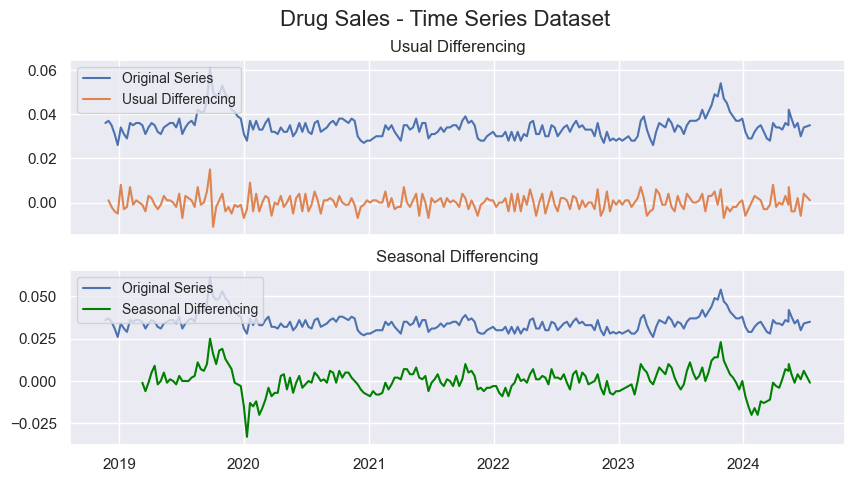

In [33]:
# Plot
fig, axes = plt.subplots(2, 1, figsize=(10,5), dpi=100, sharex=True)

# Usual Differencing
axes[0].plot(data[:], label='Original Series')
axes[0].plot(data[:].diff(1), label='Usual Differencing')
axes[0].set_title('Usual Differencing')
axes[0].legend(loc='upper left', fontsize=10)


# Seasonal Differencing
axes[1].plot(data[:], label='Original Series')
axes[1].plot(data[:].diff(12), label='Seasonal Differencing', color='green')
axes[1].set_title('Seasonal Differencing')
plt.legend(loc='upper left', fontsize=10)
plt.suptitle('Drug Sales - Time Series Dataset', fontsize=16)
plt.show()

In [34]:
import pmdarima as pm

In [35]:
# Seasonal - fit stepwise auto-ARIMA
smodel = pm.auto_arima(data, start_p=1, start_q=1,
                         test='adf',
                         max_p=3, max_q=3, m=12,
                         start_P=0, seasonal=True,
                         d=None, D=1, trace=True,
                         error_action='ignore',  
                         suppress_warnings=True, 
                         stepwise=True)

smodel.summary()

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=-1796.804, Time=0.63 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=-1515.647, Time=0.03 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=-1756.666, Time=0.73 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=-1722.238, Time=0.57 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=-1517.616, Time=0.02 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=-1701.395, Time=0.06 sec
 ARIMA(1,0,1)(1,1,1)[12] intercept   : AIC=-1773.691, Time=1.30 sec
 ARIMA(1,0,1)(0,1,2)[12] intercept   : AIC=inf, Time=2.32 sec
 ARIMA(1,0,1)(1,1,0)[12] intercept   : AIC=-1761.584, Time=1.49 sec
 ARIMA(1,0,1)(1,1,2)[12] intercept   : AIC=-1810.571, Time=3.21 sec
 ARIMA(1,0,1)(2,1,2)[12] intercept   : AIC=-1793.046, Time=5.11 sec
 ARIMA(1,0,1)(2,1,1)[12] intercept   : AIC=-1786.398, Time=3.37 sec
 ARIMA(0,0,1)(1,1,2)[12] intercept   : AIC=-1727.897, Time=3.07 sec
 ARIMA(1,0,0)(1,1,2)[12] intercept   : AIC=-1806.979, Time=3.37 sec
 ARIMA(2,0,

<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                                       y   No. Observations:                  230
Model:             SARIMAX(1, 0, 1)x(1, 1, [1, 2], 12)   Log Likelihood                 912.286
Date:                                 Wed, 07 May 2025   AIC                          -1810.571
Time:                                         15:22:26   BIC                          -1786.880
Sample:                                              0   HQIC                         -1801.002
                                                 - 230                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept  -1.469e-05      0.000     -0.146      0.884      -0.000       0.000
ar.L1          0.8258      0.054     15.207      0.000       0.719       0.932
ma.L1         -0.1558      0.092     -1.689      0.091      -0.337       0.025
ar.S.L12      -0.5528      0.953     -0.580      0.562      -2.420       1.315
ma.S.L12      -0.1757      0.936     -0.188      0.851      -2.011       1.659
ma.S.L24      -0.4617      0.689     -0.671      0.503      -1.811       0.888
sigma2      1.286e-05   1.26e-06     10.214      0.000    1.04e-05    1.53e-05
===================================================================================
Ljung-Box (L1) (Q):                   0.18   Jarque-Bera (JB):                25.95
Prob(Q):                              0.67   Prob(JB):                         0.00
Heteroskedasticity (H):               0.69   Skew:                             0.41
Prob(H) (two-sided):                  0.12   Kurtosis:                         4.48
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

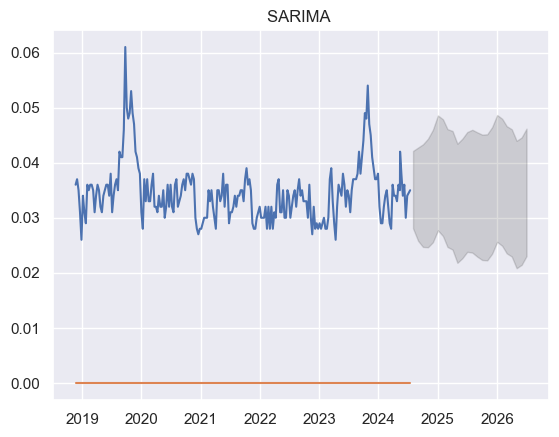

In [ ]:
# Forecast
n_periods = 24
fitted, confint = smodel.predict(n_periods=n_periods, return_conf_int=True)
index_of_fc = pd.date_range(data.index[-1], periods = n_periods, freq='MS')

# make series for plotting purpose
fitted_series = pd.Series(fitted, index=index_of_fc)
lower_series = pd.Series(confint[:, 0], index=index_of_fc)
upper_series = pd.Series(confint[:, 1], index=index_of_fc)


# make series for plotting purpose
fitted_series = pd.Series(fitted, index=index_of_fc)
lower_series = pd.Series(confint[:, 0], index=index_of_fc)
upper_series = pd.Series(confint[:, 1], index=index_of_fc)

# Plot
plt.plot(data)
plt.plot(fitted_series, color='darkgreen')
plt.fill_between(lower_series.index, 
                 lower_series, 
                 upper_series, 
                 color='k', alpha=.15)

plt.title("SARIMA ")
plt.show()

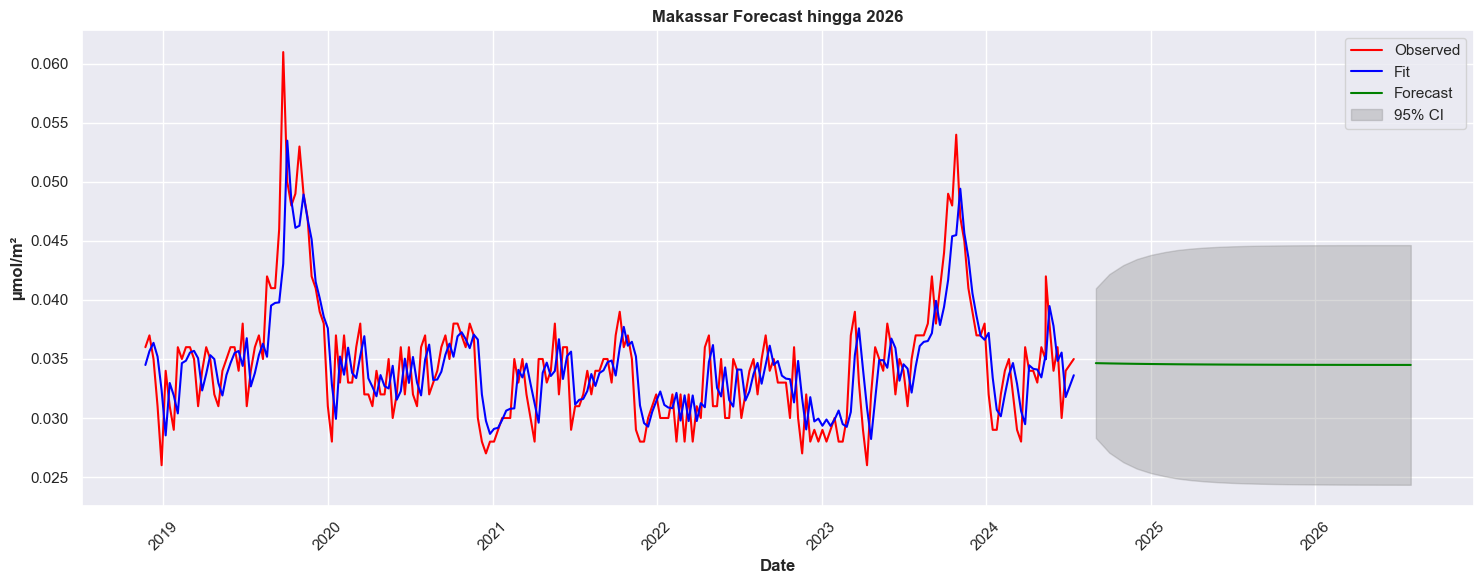

In [43]:
# Konversi kolom 'date_mks' ke datetime dan simpan di kolom 'ds'
data['date_mks'] = pd.to_datetime(data['date_mks'])

# ==== 1. Fit Model ====
model = ARIMA(data['y'], order=(1,0,1))  # Sesuaikan (p,d,q)
fitted_model = model.fit()

# ==== 2. Forecast ke Depan ====
steps_ahead = 24  # 24 bulan
forecast = fitted_model.get_forecast(steps=steps_ahead)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# ==== 3. Buat index waktu baru untuk forecast ====
last_date = data.index[-1]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=steps_ahead, freq='MS')

# make series for plotting purpose
fitted_series = pd.Series(fitted, index=index_of_fc)
lower_series = pd.Series(confint[:, 0], index=index_of_fc)
upper_series = pd.Series(confint[:, 1], index=index_of_fc)

# ==== 4. Plot ====
plt.figure(figsize=(15,6))
plt.plot(data.index, data['y'], color='red', label='Observed')
plt.plot(data.index, fitted_model.fittedvalues, color='blue', label='Fit')
plt.plot(forecast_index, forecast_mean, color='green', label='Forecast')
plt.fill_between(forecast_index, 
                 forecast_ci.iloc[:, 0], 
                 forecast_ci.iloc[:, 1], 
                 color='gray', alpha=0.3, label='95% CI')

# Format
plt.xlabel("Date", fontsize=12, weight='bold')
plt.ylabel("µmol/m²", fontsize=12, weight='bold')
plt.title("Makassar Forecast hingga 2026", weight='bold')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)  # Memutar label sumbu X
plt.tight_layout()
plt.show()
